# Analisi dei Dati Meteorologici di Londra
## 1. Setup e Importazione Librerie
In questa cella installiamo (se necessario) e importiamo tutte le librerie essenziali per l'elaborazione dei dati, la visualizzazione e l'applicazione degli algoritmi di Machine Learning.

In [3]:
# ============================================================================
# Installazione delle librerie necessarie (se non presenti)
# ============================================================================
# !pip install numpy pandas matplotlib seaborn scikit-learn yellowbrick -q

# ============================================================================
# Import delle librerie
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

## 2. Caricamento e Preprocessing del Dataset
Carichiamo il dataset `london_weather.csv`. Effettuiamo le seguenti operazioni di pulizia:
* **Normalizzazione dei nomi delle colonne:** rimuoviamo spaziature e caratteri speciali per uniformare i nomi.
* **Imputazione dei valori mancanti:** sostituiamo i valori Null con la media della rispettiva colonna per non perdere righe preziose.
* **Parsing delle date:** convertiamo la colonna `date` nel formato datetime corretto.

In [4]:
# ============================================================================
# Caricamento e preprocessing del dataset
# ============================================================================
data = pd.read_csv("london_weather.csv", sep=',')

# ✅ FIX: normalizza i nomi delle colonne
data.columns = (
    data.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[^\w]', '_', regex=True)
)

columns_to_fill = [
    "cloud_cover", "sunshine", "global_radiation", "max_temp", "mean_temp",
    "min_temp", "precipitation", "pressure", "snow_depth"
]
for col in columns_to_fill:
    data[col] = data[col].fillna(data[col].mean())

data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')

print("✅ Dataset caricato e preprocessato")
print("Colonne:", data.columns.tolist())
print("Valori mancanti residui:\n", data.isnull().sum())

✅ Dataset caricato e preprocessato
Colonne: ['date', 'cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp', 'precipitation', 'pressure', 'snow_depth']
Valori mancanti residui:
 date                0
cloud_cover         0
sunshine            0
global_radiation    0
max_temp            0
mean_temp           0
min_temp            0
precipitation       0
pressure            0
snow_depth          0
dtype: int64


## 3. Clustering delle Temperature (K-Means)
Estraiamo le variabili termiche e le standardizziamo. Utilizziamo il metodo Elbow e i punteggi Silhouette per valutare il numero di cluster, per poi applicare il K-Means con k=4, assegnando nomi ai regimi termici.

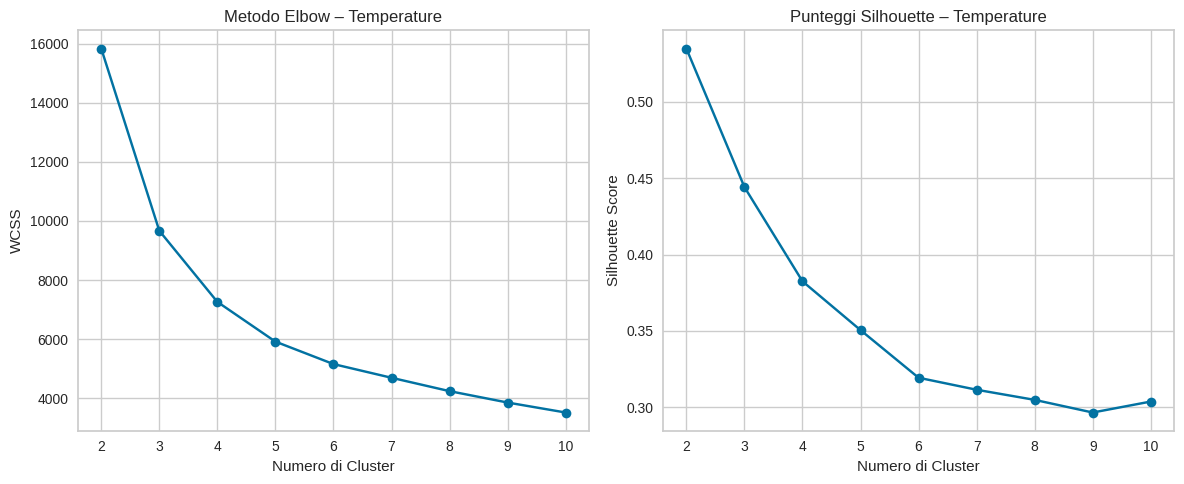


Centroidi Temperature (scala originale):
Cluster 0: max_temp=7.32 °C, mean_temp=3.60 °C, min_temp=0.16 °C
Cluster 1: max_temp=18.06 °C, mean_temp=14.05 °C, min_temp=10.04 °C
Cluster 2: max_temp=23.94 °C, mean_temp=19.10 °C, min_temp=14.18 °C
Cluster 3: max_temp=12.18 °C, mean_temp=8.90 °C, min_temp=5.47 °C


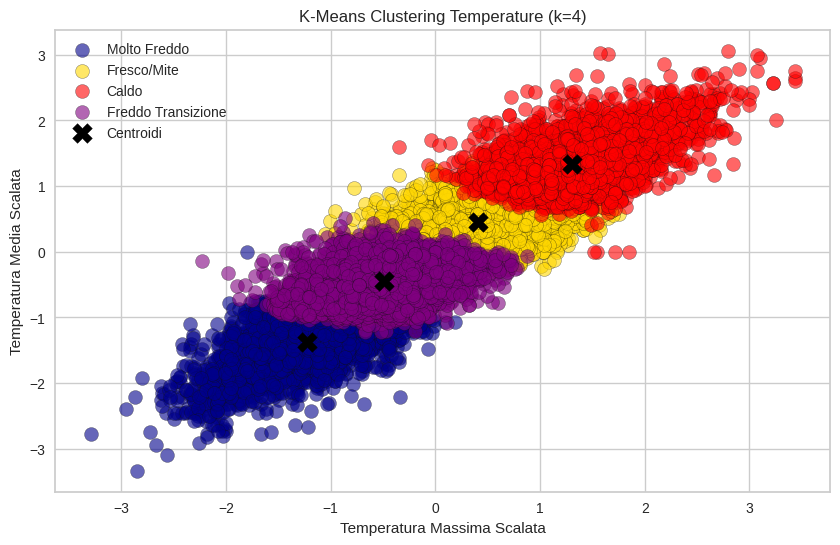

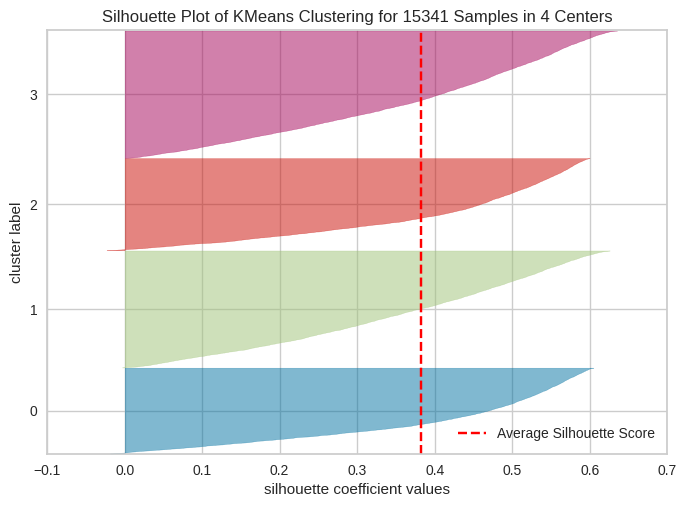


K-Means Temperature - Silhouette: 0.3825
K-Means Temperature - Davies-Bouldin: 0.8281


In [5]:
# ============================================================================
# 1. Clustering delle Temperature
# ============================================================================
x_temp = data[['max_temp', 'mean_temp', 'min_temp']].values

# Standardizzazione
scaler_temp = StandardScaler()
x_temp_scaled = scaler_temp.fit_transform(x_temp)

# Metodo Elbow e Silhouette
wcss_temp = []
sil_scores_temp = []
for i in range(2, 11):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    km.fit(x_temp_scaled)
    wcss_temp.append(km.inertia_)
    labels = km.labels_
    sil_scores_temp.append(silhouette_score(x_temp_scaled, labels))

# Grafici
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), wcss_temp, marker='o')
plt.title('Metodo Elbow – Temperature')
plt.xlabel('Numero di Cluster')
plt.ylabel('WCSS')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), sil_scores_temp, marker='o')
plt.title('Punteggi Silhouette – Temperature')
plt.xlabel('Numero di Cluster')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# K-Means con k=4
km_temp = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_km_temp = km_temp.fit_predict(x_temp_scaled)

# Centroidi in scala originale
centroids_temp_orig = scaler_temp.inverse_transform(km_temp.cluster_centers_)
print("\nCentroidi Temperature (scala originale):")
for i, c in enumerate(centroids_temp_orig):
    print(f"Cluster {i}: max_temp={c[0]:.2f} °C, mean_temp={c[1]:.2f} °C, min_temp={c[2]:.2f} °C")

# Assegnazione automatica dei nomi basata sulla temperatura media
mean_temps = centroids_temp_orig[:, 1]
sorted_idx = np.argsort(mean_temps)  # dal più freddo al più caldo
temp_names = ['Molto Freddo', 'Freddo Transizione', 'Fresco/Mite', 'Caldo']
cluster_to_name_temp = {sorted_idx[i]: temp_names[i] for i in range(4)}

# Colori coerenti
color_map_temp = {
    'Molto Freddo': 'darkblue',
    'Freddo Transizione': 'purple',
    'Fresco/Mite': 'gold',
    'Caldo': 'red'
}

# Visualizzazione K-Means
plt.figure(figsize=(10, 6))
for cluster_id in range(4):
    name = cluster_to_name_temp[cluster_id]
    plt.scatter(x_temp_scaled[y_km_temp == cluster_id, 0],
                x_temp_scaled[y_km_temp == cluster_id, 1],
                s=100, c=color_map_temp[name], label=name, alpha=0.6, edgecolors='k')
plt.scatter(km_temp.cluster_centers_[:, 0], km_temp.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroidi')
plt.title('K-Means Clustering Temperature (k=4)')
plt.xlabel('Temperatura Massima Scalata')
plt.ylabel('Temperatura Media Scalata')
plt.legend()
plt.show()

# Silhouette plot
visualizer_temp = SilhouetteVisualizer(km_temp, colors='yellowbrick')
visualizer_temp.fit(x_temp_scaled)
visualizer_temp.show()

# Metriche
km_sil_temp = silhouette_score(x_temp_scaled, y_km_temp)
km_db_temp = davies_bouldin_score(x_temp_scaled, y_km_temp)
print(f"\nK-Means Temperature - Silhouette: {km_sil_temp:.4f}")
print(f"K-Means Temperature - Davies-Bouldin: {km_db_temp:.4f}")

## 4. Clustering Gerarchico e Statistiche (Temperature)
Applichiamo l'Agglomerative Clustering per confronto, stampiamo le metriche di valutazione e generiamo le statistiche descrittive

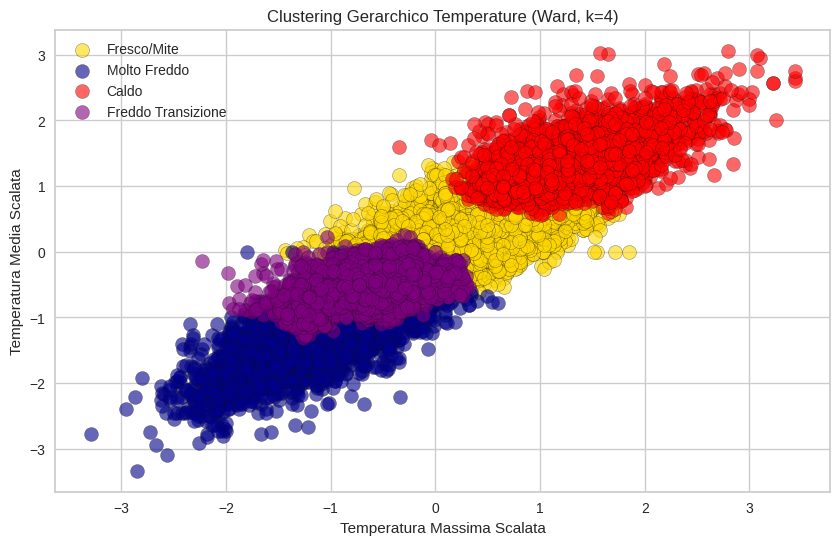

Agglomerative Temperature - Silhouette: 0.3478
Agglomerative Temperature - Davies-Bouldin: 0.8589

Statistiche descrittive Temperature per cluster:
                   max_temp                                               \
                      count       mean       std   min   25%   50%   75%   
temp_cluster_name                                                          
Caldo                3347.0  23.948103  3.296542  13.1  21.5  23.6  26.0   
Freddo Transizione   4627.0  12.180285  2.665223   0.8  10.4  12.2  13.9   
Fresco/Mite          4249.0  18.064499  2.735982   8.5  16.2  18.1  19.9   
Molto Freddo         3118.0   7.315811  3.170463  -6.2   5.1   7.5   9.6   

                         mean_temp             ...                  min_temp  \
                     max     count       mean  ...   75%        max    count   
temp_cluster_name                              ...                             
Caldo               37.9    3347.0  19.101435  ...  20.3  29.000000   3347.0   

In [6]:
# Clustering gerarchico Temperature – mapping corretto tramite centroidi
hc_temp = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_hc_temp = hc_temp.fit_predict(x_temp_scaled)

# Calcola centroidi del clustering gerarchico e ordina per temperatura media
centroids_hc_temp = np.array([
    x_temp_scaled[y_hc_temp == i].mean(axis=0) for i in range(4)
])
centroids_hc_temp_orig = scaler_temp.inverse_transform(centroids_hc_temp)
hc_mean_temps = centroids_hc_temp_orig[:, 1]
hc_sorted_idx = np.argsort(hc_mean_temps)
cluster_to_name_hc_temp = {hc_sorted_idx[i]: temp_names[i] for i in range(4)}

plt.figure(figsize=(10, 6))
for cluster_id in range(4):
    name = cluster_to_name_hc_temp[cluster_id]
    plt.scatter(x_temp_scaled[y_hc_temp == cluster_id, 0],
                x_temp_scaled[y_hc_temp == cluster_id, 1],
                s=100, c=color_map_temp[name], label=name, alpha=0.6, edgecolors='k')
plt.title('Clustering Gerarchico Temperature (Ward, k=4)')
plt.xlabel('Temperatura Massima Scalata')
plt.ylabel('Temperatura Media Scalata')
plt.legend()
plt.show()

hc_sil_temp = silhouette_score(x_temp_scaled, y_hc_temp)
hc_db_temp = davies_bouldin_score(x_temp_scaled, y_hc_temp)
print(f"Agglomerative Temperature - Silhouette: {hc_sil_temp:.4f}")
print(f"Agglomerative Temperature - Davies-Bouldin: {hc_db_temp:.4f}")

# Statistiche descrittive per LaTeX
data['temp_cluster_name'] = [cluster_to_name_temp[lab] for lab in y_km_temp]
print("\nStatistiche descrittive Temperature per cluster:")
print(data.groupby('temp_cluster_name')[['max_temp', 'mean_temp', 'min_temp']].describe())

# Tabella LaTeX centroidi temperature
print("\n--- Tabella LaTeX Centroidi Temperature ---")
print("\\begin{table}[H]\n\\centering\n\\caption{Centroidi dei cluster di temperatura in scala originale (°C).}\n\\label{tab:centroids_temp}\n\\begin{tabular}{lccc}\n\\hline\n\\textbf{Regime} & \\textbf{max\\_temp} & \\textbf{mean\\_temp} & \\textbf{min\\_temp} \\\\\n\\hline")
for name in temp_names:
    idx = [k for k, v in cluster_to_name_temp.items() if v == name][0]
    c = centroids_temp_orig[idx]
    print(f"{name} & {c[0]:.1f} & {c[1]:.1f} & {c[2]:.1f} \\\\")
print("\\hline\n\\end{tabular}\n\\end{table}")

## 5. Clustering Radiazione Solare e Precipitazioni (K-Means)
Passiamo all'analisi di radiazione solare e pioggia. Analizziamo le curve Elbow e Silhouette, applichiamo K-Means (k=4) e classifichiamo i cluster ordinandoli in base a precipitazioni e radiazione.

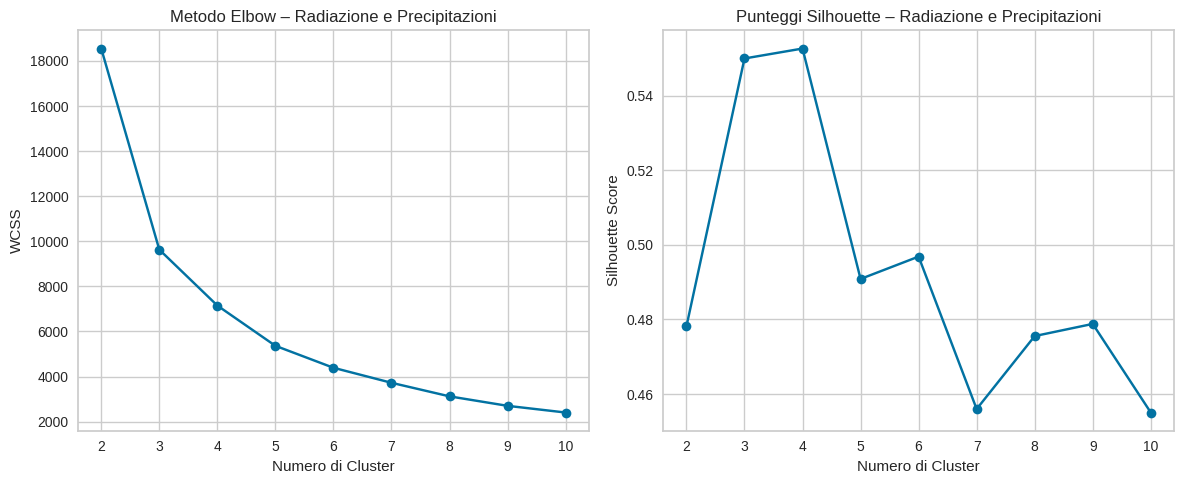


Centroidi Radiazione e Precipitazioni (scala originale):
Cluster 0: global_radiation=73.56 W/m², precipitation=7.49 mm
Cluster 1: global_radiation=224.79 W/m², precipitation=0.44 mm
Cluster 2: global_radiation=62.51 W/m², precipitation=0.61 mm
Cluster 3: global_radiation=82.61 W/m², precipitation=21.14 mm


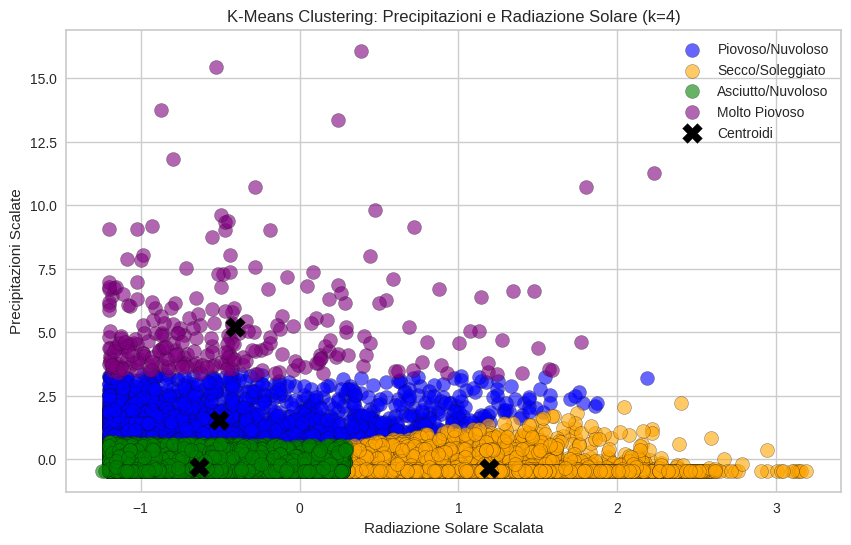

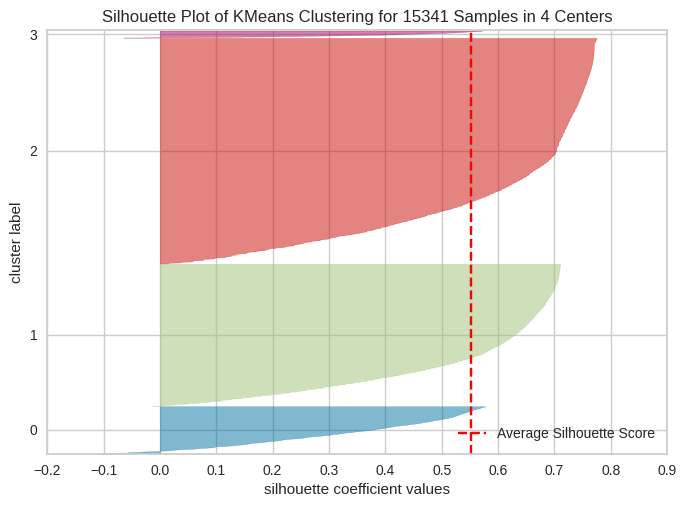


K-Means Rad/Precip - Silhouette: 0.5526
K-Means Rad/Precip - Davies-Bouldin: 0.6698


In [7]:
# ============================================================================
# 2. Clustering Radiazione Solare e Precipitazioni
# ============================================================================
x_rad = data[['global_radiation', 'precipitation']].values
scaler_rad = StandardScaler()
x_rad_scaled = scaler_rad.fit_transform(x_rad)

# Metodo Elbow e Silhouette
wcss_rad = []
sil_scores_rad = []
for i in range(2, 11):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    km.fit(x_rad_scaled)
    wcss_rad.append(km.inertia_)
    sil_scores_rad.append(silhouette_score(x_rad_scaled, km.labels_))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 11), wcss_rad, marker='o')
plt.title('Metodo Elbow – Radiazione e Precipitazioni')
plt.xlabel('Numero di Cluster')
plt.ylabel('WCSS')
plt.subplot(1, 2, 2)
plt.plot(range(2, 11), sil_scores_rad, marker='o')
plt.title('Punteggi Silhouette – Radiazione e Precipitazioni')
plt.xlabel('Numero di Cluster')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# K-Means con k=4
km_rad = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_km_rad = km_rad.fit_predict(x_rad_scaled)

centroids_rad_orig = scaler_rad.inverse_transform(km_rad.cluster_centers_)
print("\nCentroidi Radiazione e Precipitazioni (scala originale):")
for i, c in enumerate(centroids_rad_orig):
    print(f"Cluster {i}: global_radiation={c[0]:.2f} W/m², precipitation={c[1]:.2f} mm")

# Assegnazione robusta dei nomi ai cluster tramite ordinamento
# Ordiniamo per precipitation crescente, a parità per radiation decrescente
centroids_with_idx = list(enumerate(centroids_rad_orig))
centroids_sorted = sorted(centroids_with_idx, key=lambda x: (x[1][1], -x[1][0]))

rad_names_ordered = ['Secco/Soleggiato', 'Asciutto/Nuvoloso', 'Piovoso/Nuvoloso', 'Molto Piovoso']
cluster_to_name_rad = {}
for (orig_idx, _), name in zip(centroids_sorted, rad_names_ordered):
    cluster_to_name_rad[orig_idx] = name

color_map_rad = {
    'Secco/Soleggiato': 'orange',
    'Asciutto/Nuvoloso': 'green',
    'Piovoso/Nuvoloso': 'blue',
    'Molto Piovoso': 'purple'
}

# Visualizzazione K-Means
plt.figure(figsize=(10, 6))
for cluster_id in range(4):
    name = cluster_to_name_rad[cluster_id]
    plt.scatter(x_rad_scaled[y_km_rad == cluster_id, 0],
                x_rad_scaled[y_km_rad == cluster_id, 1],
                s=100, c=color_map_rad[name], label=name, alpha=0.6, edgecolors='k')
plt.scatter(km_rad.cluster_centers_[:, 0], km_rad.cluster_centers_[:, 1],
            s=200, c='black', marker='X', label='Centroidi')
plt.title('K-Means Clustering: Precipitazioni e Radiazione Solare (k=4)')
plt.xlabel('Radiazione Solare Scalata')
plt.ylabel('Precipitazioni Scalate')
plt.legend()
plt.show()

# Silhouette plot
visualizer_rad = SilhouetteVisualizer(km_rad, colors='yellowbrick')
visualizer_rad.fit(x_rad_scaled)
visualizer_rad.show()

# Metriche
km_sil_rad = silhouette_score(x_rad_scaled, y_km_rad)
km_db_rad = davies_bouldin_score(x_rad_scaled, y_km_rad)
print(f"\nK-Means Rad/Precip - Silhouette: {km_sil_rad:.4f}")
print(f"K-Means Rad/Precip - Davies-Bouldin: {km_db_rad:.4f}")

## 6. Clustering Gerarchico e Statistiche (Rad/Precip)
Confronto con il clustering agglomerativo, recupero delle statistiche descrittive del dataset

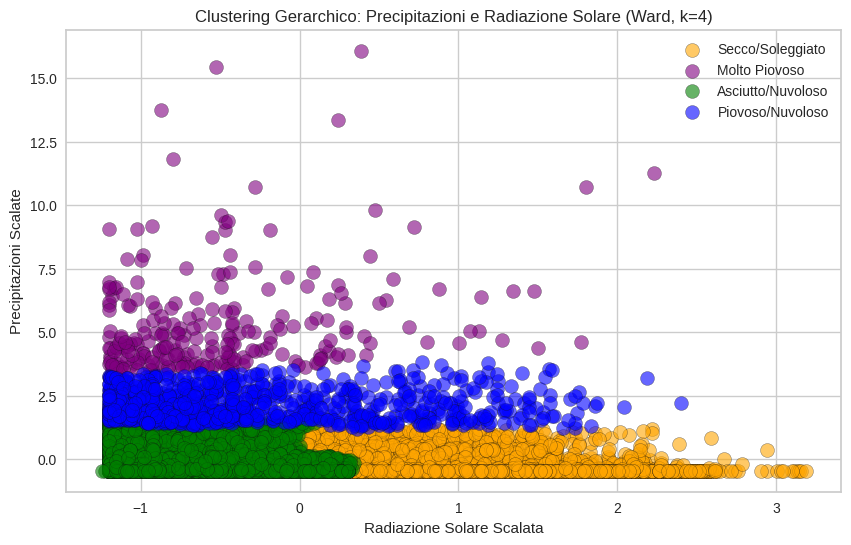

Agglomerative Rad/Precip - Silhouette: 0.5360
Agglomerative Rad/Precip - Davies-Bouldin: 0.7053

Statistiche descrittive Rad/Precip per cluster:
                  global_radiation                                       \
                             count        mean        std    min    25%   
rad_cluster_name                                                          
Asciutto/Nuvoloso           8198.0   62.503462  38.462276    8.0   29.0   
Molto Piovoso                258.0   82.612403  63.479070   12.0   34.0   
Piovoso/Nuvoloso            1717.0   73.620850  58.388380   12.0   26.0   
Secco/Soleggiato            5168.0  224.792183  52.395429  144.0  181.0   

                                       precipitation                       \
                     50%    75%    max         count       mean       std   
rad_cluster_name                                                            
Asciutto/Nuvoloso   55.0   92.0  145.0        8198.0   0.611463  1.008921   
Molto Piovoso       7

In [8]:
# Clustering gerarchico Rad/Precip – mapping corretto tramite centroidi
hc_rad = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_hc_rad = hc_rad.fit_predict(x_rad_scaled)

# Calcola centroidi del clustering gerarchico e ordina come per K-Means
centroids_hc_rad = np.array([
    x_rad_scaled[y_hc_rad == i].mean(axis=0) for i in range(4)
])
centroids_hc_rad_orig = scaler_rad.inverse_transform(centroids_hc_rad)
centroids_hc_with_idx = list(enumerate(centroids_hc_rad_orig))
centroids_hc_sorted = sorted(centroids_hc_with_idx, key=lambda x: (x[1][1], -x[1][0]))
cluster_to_name_hc_rad = {}
for (orig_idx, _), name in zip(centroids_hc_sorted, rad_names_ordered):
    cluster_to_name_hc_rad[orig_idx] = name

plt.figure(figsize=(10, 6))
for cluster_id in range(4):
    name = cluster_to_name_hc_rad[cluster_id]
    plt.scatter(x_rad_scaled[y_hc_rad == cluster_id, 0],
                x_rad_scaled[y_hc_rad == cluster_id, 1],
                s=100, c=color_map_rad[name], label=name, alpha=0.6, edgecolors='k')
plt.title('Clustering Gerarchico: Precipitazioni e Radiazione Solare (Ward, k=4)')
plt.xlabel('Radiazione Solare Scalata')
plt.ylabel('Precipitazioni Scalate')
plt.legend()
plt.show()

hc_sil_rad = silhouette_score(x_rad_scaled, y_hc_rad)
hc_db_rad = davies_bouldin_score(x_rad_scaled, y_hc_rad)
print(f"Agglomerative Rad/Precip - Silhouette: {hc_sil_rad:.4f}")
print(f"Agglomerative Rad/Precip - Davies-Bouldin: {hc_db_rad:.4f}")

# Statistiche descrittive
data['rad_cluster_name'] = [cluster_to_name_rad[lab] for lab in y_km_rad]
print("\nStatistiche descrittive Rad/Precip per cluster:")
print(data.groupby('rad_cluster_name')[['global_radiation', 'precipitation']].describe())

# Tabella LaTeX centroidi
print("\n--- Tabella LaTeX Centroidi Rad/Precip ---")
print("\\begin{table}[H]\n\\centering\n\\caption{Centroidi dei cluster per radiazione e precipitazioni (unità originali).}\n\\label{tab:centroids_rad}\n\\begin{tabular}{lcc}\n\\hline\n\\textbf{Regime} & \\textbf{global\\_radiation (W/m²)} & \\textbf{precipitation (mm)} \\\\\n\\hline")
for name in rad_names_ordered:
    orig_idx = [k for k, v in cluster_to_name_rad.items() if v == name][0]
    c = centroids_rad_orig[orig_idx]
    print(f"{name} & {c[0]:.1f} & {c[1]:.2f} \\\\")
print("\\hline\n\\end{tabular}\n\\end{table}")

# Tabella LaTeX statistiche descrittive (esempio con media)
print("\n--- Tabella LaTeX Statistiche Descrittive Rad/Precip (media ± std) ---")
print("\\begin{table}[H]\n\\centering\n\\caption{Statistiche descrittive medie (media $\\pm$ deviazione standard) per ciascun regime di radiazione e precipitazioni.}\n\\label{tab:desc_rad}\n\\begin{tabular}{lcccc}\n\\hline\n\\textbf{Regime} & \\textbf{Radiazione (W/m²)} & \\textbf{Precipitazione (mm)} & \\textbf{Conteggio} \\\\\n\\hline")
for name in rad_names_ordered:
    subset = data[data['rad_cluster_name'] == name]
    cnt = len(subset)
    mu_rad = subset['global_radiation'].mean()
    std_rad = subset['global_radiation'].std()
    mu_prec = subset['precipitation'].mean()
    std_prec = subset['precipitation'].std()
    print(f"{name} & ${mu_rad:.1f} \\pm {std_rad:.1f}$ & ${mu_prec:.2f} \\pm {std_prec:.2f}$ & {cnt} \\\\")
print("\\hline\n\\end{tabular}\n\\end{table}")

## 7. PCA e Test DBSCAN Singolo (eps=0.5)
Riduciamo le dimensioni usando la PCA per facilitare la visualizzazione. Dopodiché, eseguiamo una prima applicazione esplorativa del DBSCAN impostando eps a 0.5 per analizzare la quantità di cluster formati e il rumore.

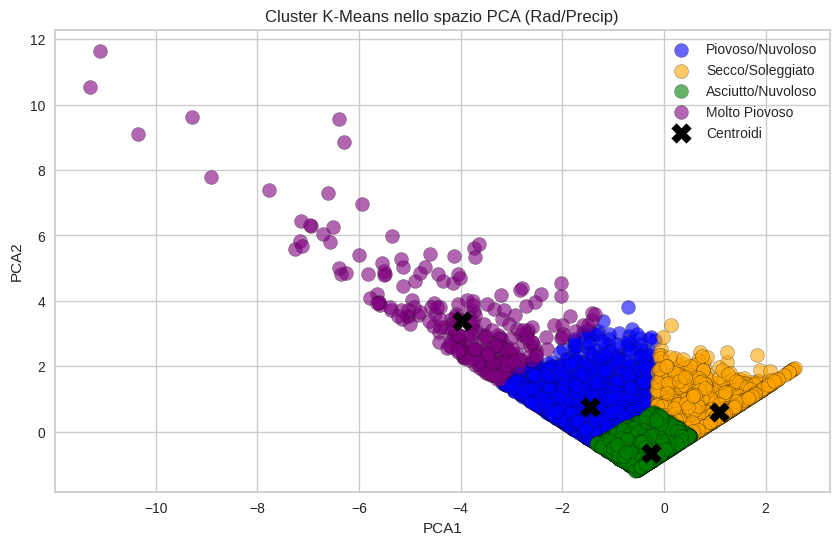


DBSCAN Esplorativo (eps=0.5): 3 cluster, 19 punti di rumore


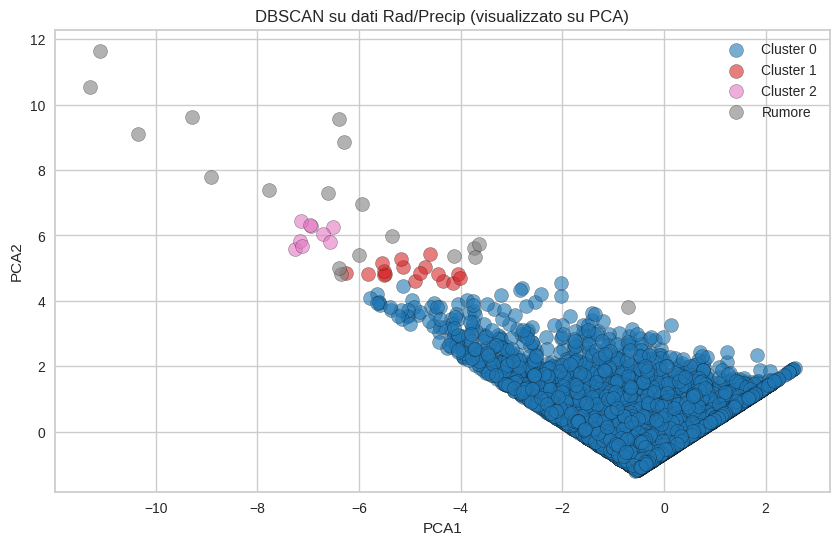

In [9]:
# ============================================================================
# PCA e DBSCAN (su dati Radiazione/Precipitazioni)
# ============================================================================
pca = PCA(n_components=2)
pca_rad_scaled = pca.fit_transform(x_rad_scaled)

# Visualizzazione K-Means nello spazio PCA
plt.figure(figsize=(10, 6))
for cluster_id in range(4):
    name = cluster_to_name_rad[cluster_id]
    plt.scatter(pca_rad_scaled[y_km_rad == cluster_id, 0],
                pca_rad_scaled[y_km_rad == cluster_id, 1],
                s=100, c=color_map_rad[name], label=name, alpha=0.6, edgecolors='k')
centers_pca = pca.transform(km_rad.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=200, c='black', marker='X', label='Centroidi')
plt.title('Cluster K-Means nello spazio PCA (Rad/Precip)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()

# Esecuzione DBSCAN esplorativo (eps=0.5)
# Nota: La scelta di eps=0.5 viene giustificata graficamente nella cella successiva
db = DBSCAN(eps=0.5, min_samples=5)
y_db = db.fit_predict(x_rad_scaled)
n_clusters_db = len(set(y_db)) - (1 if -1 in y_db else 0)
n_noise = list(y_db).count(-1)
print(f"\nDBSCAN Esplorativo (eps=0.5): {n_clusters_db} cluster, {n_noise} punti di rumore")

# Visualizzazione DBSCAN su PCA
plt.figure(figsize=(10, 6))
unique_labels = set(y_db)
colors_db = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for k, col in zip(unique_labels, colors_db):
    if k == -1:
        col = [0.5, 0.5, 0.5, 1]  # grigio per il rumore
    mask = (y_db == k)
    plt.scatter(pca_rad_scaled[mask, 0], pca_rad_scaled[mask, 1],
                s=100, color=col, label=f'Cluster {k}' if k != -1 else 'Rumore',
                alpha=0.6, edgecolors='k')
plt.title('DBSCAN su dati Rad/Precip (visualizzato su PCA)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()

## 8. Curva K-distance (Scelta parametri DBSCAN)
Tracciamo in modo approfondito la curva delle distanze del k-esimo vicino per identificare graficamente le diverse soglie di eps da testare successivamente.

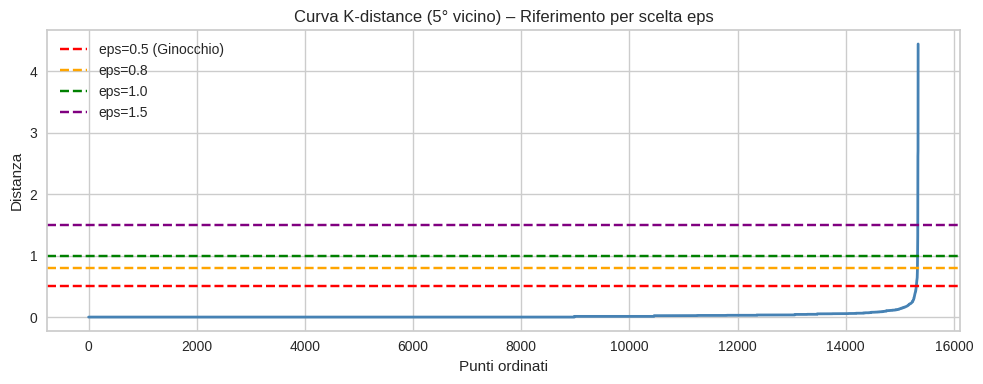

In [10]:
# ============================================================================
# Curva K-distance per scegliere eps (Corretta con n_neighbors=5)
# ============================================================================
from sklearn.neighbors import NearestNeighbors

min_samples = 5

# Impostiamo n_neighbors=5 per allinearci al min_samples del DBSCAN
neigh = NearestNeighbors(n_neighbors=min_samples)
neigh.fit(x_rad_scaled)
distances, _ = neigh.kneighbors(x_rad_scaled)

# Ordiniamo le distanze rispetto al 5° vicino (indice 4)
distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(10, 4))
plt.plot(distances, color='steelblue', lw=2)
plt.axhline(y=0.5, color='red',    linestyle='--', label='eps=0.5 (Ginocchio)')
plt.axhline(y=0.8, color='orange', linestyle='--', label='eps=0.8')
plt.axhline(y=1.0, color='green',  linestyle='--', label='eps=1.0')
plt.axhline(y=1.5, color='purple', linestyle='--', label='eps=1.5')
plt.title('Curva K-distance (5° vicino) – Riferimento per scelta eps')
plt.xlabel('Punti ordinati')
plt.ylabel('Distanza')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Confronto DBSCAN con 6 valori di eps
Eseguiamo un test sistematico dell'algoritmo DBSCAN iterando su una lista di 6 possibili valori di `eps`. Per ogni valore viene generato un grafico a dispersione sulle componenti PCA per mostrare la classificazione dei punti (cluster validi contro rumore).

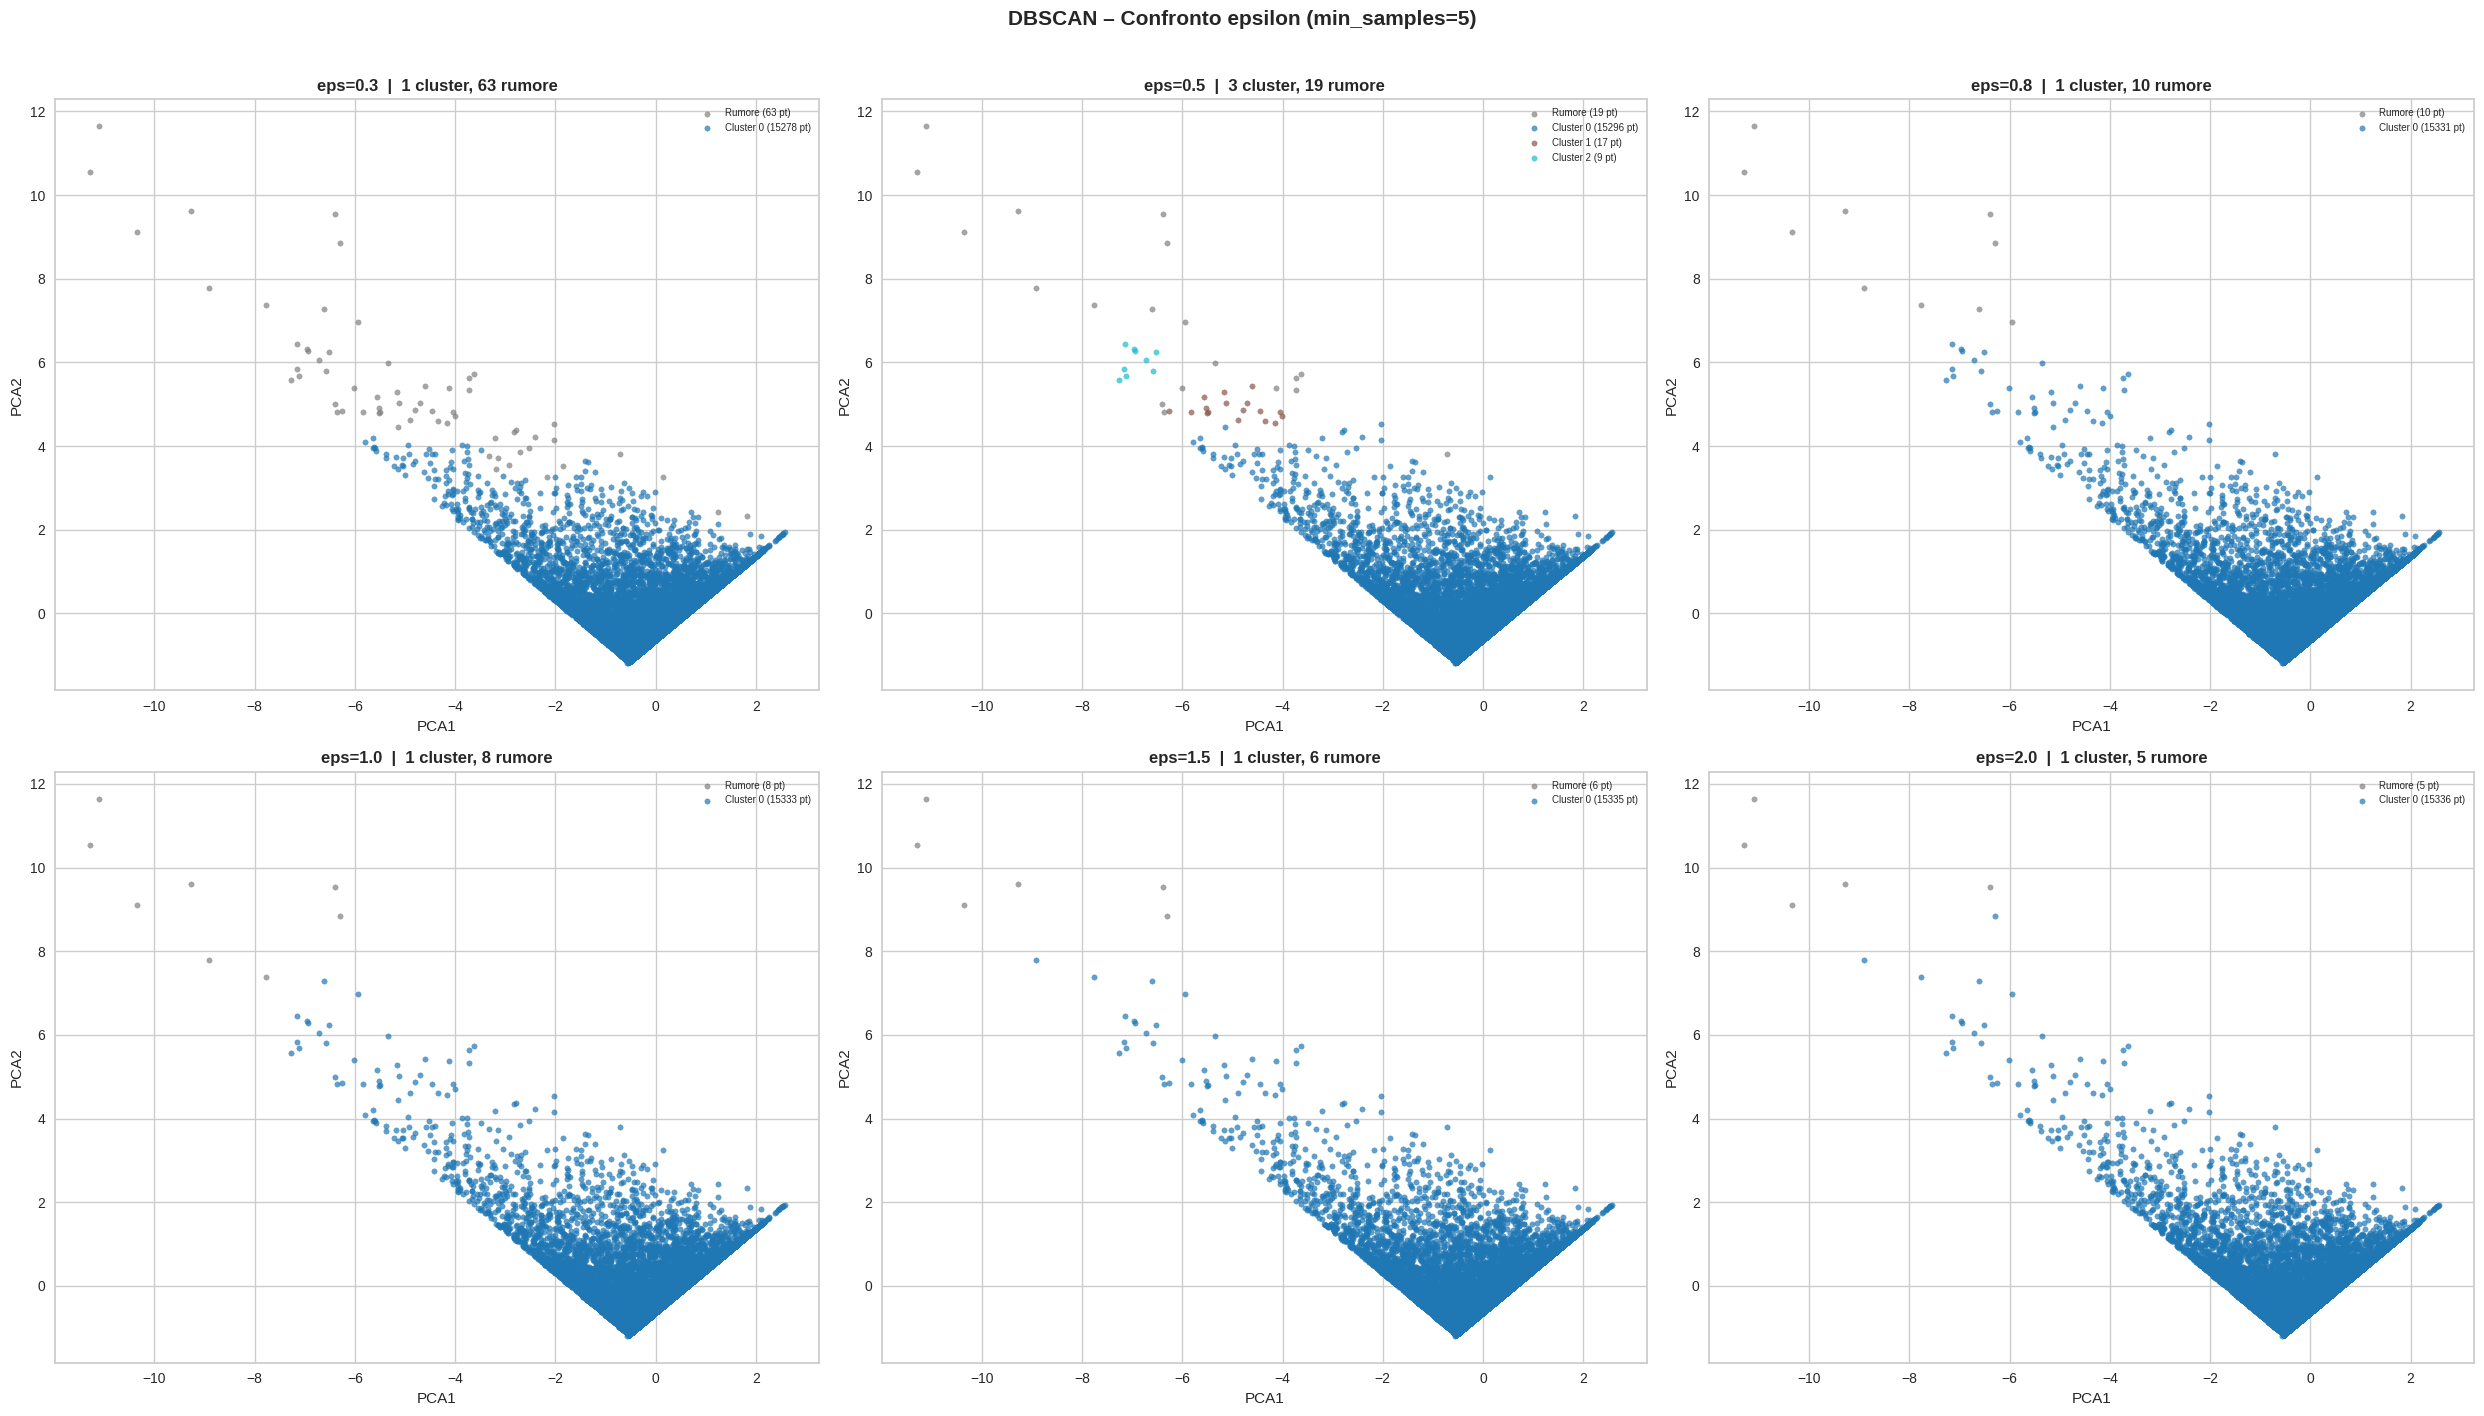

In [11]:
# ============================================================================
# DBSCAN con 6 valori di eps a confronto
# ============================================================================
eps_values = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]
min_samples = 5

fig, axes = plt.subplots(2, 3, figsize=(25, 14))
axes = axes.flatten()

for ax, eps in zip(axes, eps_values):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    y_db = db.fit_predict(x_rad_scaled)

    n_clusters = len(set(y_db)) - (1 if -1 in y_db else 0)
    n_noise    = list(y_db).count(-1)

    unique_labels = sorted(set(y_db))
    # palette: grigio per rumore (-1), colori distinti per i cluster
    palette = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))
    color_idx = 0

    for k in unique_labels:
        mask = (y_db == k)
        if k == -1:
            color = [0.5, 0.5, 0.5, 0.6]
            label = f'Rumore ({n_noise} pt)'
        else:
            color = palette[color_idx]
            color_idx += 1
            label = f'Cluster {k} ({mask.sum()} pt)'

        ax.scatter(pca_rad_scaled[mask, 0], pca_rad_scaled[mask, 1],
                   s=15, color=color, label=label, alpha=0.7)

    ax.set_title(f'eps={eps}  |  {n_clusters} cluster, {n_noise} rumore',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('PCA1')
    ax.set_ylabel('PCA2')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('DBSCAN – Confronto epsilon (min_samples=5)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. Tabella Riepilogativa Finale DBSCAN
Generiamo in output una tabella testuale che riassume numericamente il comportamento del DBSCAN al variare di `eps`, evidenziando quanti cluster si formano, quanti punti vengono scartati e la relativa percentuale di rumore.

In [12]:
# ============================================================================
# Tabella riepilogativa
# ============================================================================
print(f"\n{'eps':>6} | {'Cluster':>8} | {'Rumore':>8} | {'% Rumore':>10}")
print("-" * 42)
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    y_db = db.fit_predict(x_rad_scaled)
    n_clusters = len(set(y_db)) - (1 if -1 in y_db else 0)
    n_noise    = list(y_db).count(-1)
    pct_noise  = n_noise / len(y_db) * 100
    print(f"{eps:>6} | {n_clusters:>8} | {n_noise:>8} | {pct_noise:>9.1f}%")

print("\n✅ Analisi completata.")


   eps |  Cluster |   Rumore |   % Rumore
------------------------------------------
   0.3 |        1 |       63 |       0.4%
   0.5 |        3 |       19 |       0.1%
   0.8 |        1 |       10 |       0.1%
   1.0 |        1 |        8 |       0.1%
   1.5 |        1 |        6 |       0.0%
   2.0 |        1 |        5 |       0.0%

✅ Analisi completata.
